# GALAXY SIMULATION

In [1]:
import numpy as np
import numpy.fft as fft
import pylab as plt
import pyccl as ccl
#plt.rcParams["figure.figsize"] = (14,7)
import fastbox
from fastbox.box import CosmoBox, default_cosmo
from fastbox.foregrounds import ForegroundModel

import time, sys

## Galaxy catalog

In [2]:
box = CosmoBox(cosmo=default_cosmo, box_scale=(1e3,1e3,1e3), nsamp=64, 
               redshift=0.8, realise_now=False)
box.realise_density()

delta_field = box.lognormal(box.delta_x)

# Initialise the Galaxy Tracer
mean_density = 1e-3 # galaxies per Mpc^3
bias = 1.5

gal_tracer = fastbox.tracers.GalaxyTracer(box=box, vol_density=mean_density, bias=bias)

# Generate the coordinate catalogue
galaxy_coordinates = gal_tracer.generate_catalogue(delta_field)

print(f"Generated {len(galaxy_coordinates)} galaxies.")

Generated 999814 galaxies.


 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/pyccl/pk2d.py:207: RuntimeWarning:divide by zero encountered in log


## MASS ASSIGNMENT

In [3]:
# You can start a mesh from scratch, I.E, generating a gal simulation internally
ngp_mesh = gal_tracer.generate_mesh(delta_field, method='NGP',overdensity=False)
cic_mesh = gal_tracer.generate_mesh(delta_field, method='CIC',overdensity=False)

# Or you can pass the catalog previously generated

mesh = gal_tracer._assign_ngp(galaxy_coordinates)

### sliceplot

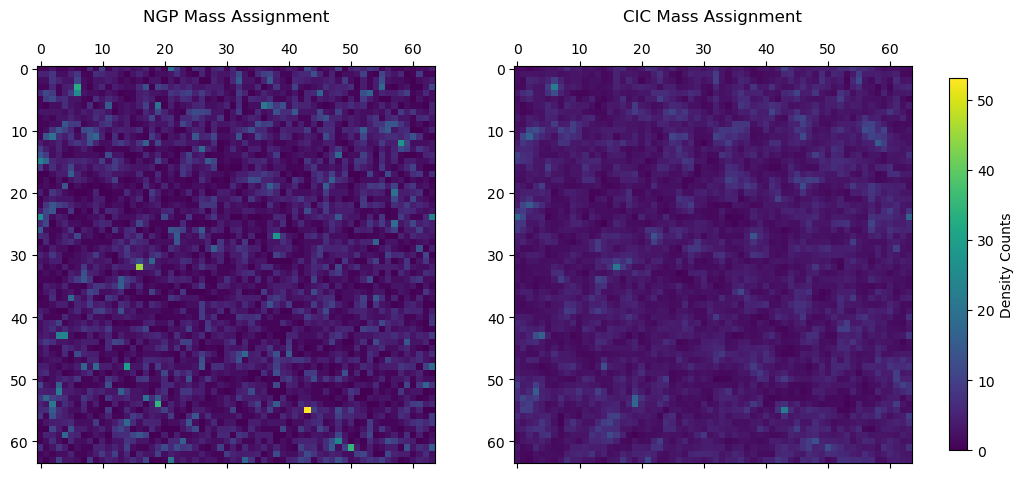

In [4]:
slice_ngp = ngp_mesh[:,:,0]
slice_cic = cic_mesh[:,:,0]

vmin = min(slice_ngp.min(), slice_cic.min())
vmax = max(slice_ngp.max(), slice_cic.max())

# 2. Create the side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 3. Plot NGP
im1 = axes[0].matshow(slice_ngp, vmin=vmin, vmax=vmax)
axes[0].set_title('NGP Mass Assignment', pad=15)

# 4. Plot CIC
im2 = axes[1].matshow(slice_cic, vmin=vmin, vmax=vmax)
axes[1].set_title('CIC Mass Assignment', pad=15)

# 5. Add a single shared colorbar
# Using fraction and pad helps keep the colorbar scaled correctly with the plots
fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label='Density Counts')

plt.show()

### pdf

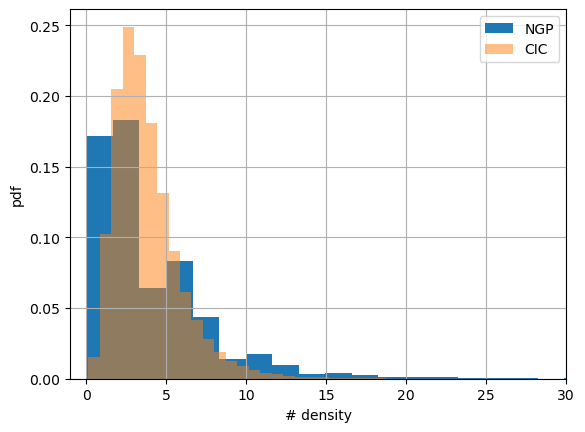

In [5]:
plt.hist(ngp_mesh.flatten(),bins=50, density=True,label='NGP')
plt.hist(cic_mesh.flatten(),bins=50, density=True,alpha=0.5,label='CIC')
plt.legend()
plt.xlim(-1,30)
plt.grid()
plt.ylabel('pdf')
plt.xlabel('# density')
plt.show()

## RSD

In [6]:
galaxy_coordinates_rsd = gal_tracer.apply_rsd(galaxy_coordinates, sigma_nl=120) # APP FOG AND KAISER

 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/fastbox-0.0.9-py3.8.egg/fastbox/box.py:254: RuntimeWarning:invalid value encountered in true_divide
 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/fastbox-0.0.9-py3.8.egg/fastbox/box.py:255: RuntimeWarning:invalid value encountered in true_divide
 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/fastbox-0.0.9-py3.8.egg/fastbox/box.py:256: RuntimeWarning:invalid value encountered in true_divide


### (1/ngal)dn/dz

In [7]:
red_bins = 1420/box.freq_array()-1
dz = np.abs(np.gradient(red_bins))

In [8]:
mesh_rsd = gal_tracer._assign_ngp(galaxy_coordinates_rsd)

In [9]:
dndz_ngal     = np.sum(mesh,axis=(0,1))/(galaxy_coordinates.shape[0]*dz)
dndz_ngal_rsd = np.sum(mesh_rsd,axis=(0,1))/(galaxy_coordinates_rsd.shape[0]*dz)

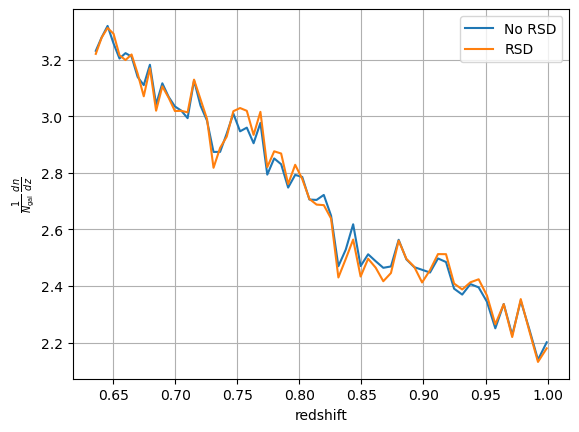

In [10]:
plt.plot(red_bins,dndz_ngal, label='No RSD')
plt.plot(red_bins,dndz_ngal_rsd, label='RSD')
plt.legend()
plt.grid()
plt.ylabel(r'$\frac{1}{N_{\rm gal}}\,\frac{dn}{dz}$')
plt.xlabel('redshift')
plt.show()

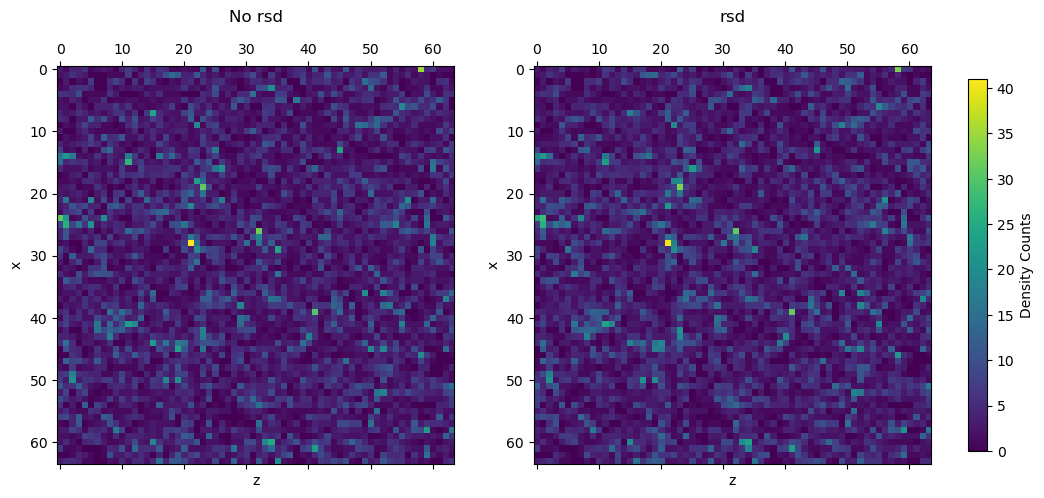

In [11]:
slice_no = mesh[:,0,:]
slice_rsd = mesh_rsd[:,0,:]

vmin = min(slice_no.min(), slice_rsd.min())
vmax = max(slice_no.max(), slice_rsd.max())

# 2. Create the side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 3. Plot NGP
im1 = axes[0].matshow(slice_no, vmin=vmin, vmax=vmax)
axes[0].set_title('No rsd', pad=15)
axes[0].set_ylabel('x')
axes[0].set_xlabel('z')

# 4. Plot CIC
im2 = axes[1].matshow(slice_rsd, vmin=vmin, vmax=vmax)
axes[1].set_title('rsd', pad=15)
axes[1].set_ylabel('x')
axes[1].set_xlabel('z')

# 5. Add a single shared colorbar
fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label='Density Counts')

plt.show()

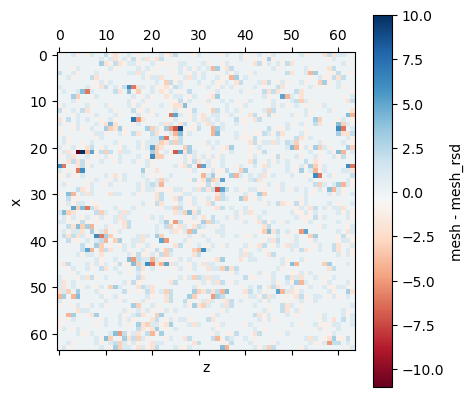

In [17]:
plt.matshow(mesh[:,0,:]-mesh_rsd[:,0,:],cmap='RdBu')
plt.colorbar(label='mesh - mesh_rsd')
plt.xlabel('z')
plt.ylabel('x')
plt.show()